In [762]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [763]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

# train.head()
train.info()
# train["Age"].median()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [764]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [765]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [766]:
train = train.drop(columns=["Cabin"])
test = test.drop(columns=["Cabin"])

In [767]:
train[ train["Embarked"].isnull() ]
# train.loc[ train["Embarked"].isnull(), "Embarked" ]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,NaN


In [768]:
# train = train.fillna(method="ffill")   # เติมด้วยค่าก่อนหน้า
# train = train.fillna(method="bfill")   # เติมด้วยค่าถัดไป

train["Age"] = train["Age"].fillna(train["Age"].median())
test["Age"] = test["Age"].fillna(train["Age"].median())
train["Embarked"] = train["Embarked"].fillna(train["Embarked"].mode()[0])

train.iloc[55:65]
# train.iloc[825:835]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
55,56,1,1,"Woolner, Mr. Hugh",male,28.0,0,0,19947,35.5000,S
56,57,1,2,"Rugg, Miss. Emily",female,21.0,0,0,C.A. 31026,10.5000,S
57,58,0,3,"Novel, Mr. Mansouer",male,28.5,0,0,2697,7.2292,C
58,59,1,2,"West, Miss. Constance Mirium",female,5.0,1,2,C.A. 34651,27.7500,S
59,60,0,3,"Goodwin, Master. William Frederick",male,11.0,5,2,CA 2144,46.9000,S
60,61,0,3,"Sirayanian, Mr. Orsen",male,22.0,0,0,2669,7.2292,C
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0000,S
62,63,0,1,"Harris, Mr. Henry Birkhardt",male,45.0,1,0,36973,83.4750,S
63,64,0,3,"Skoog, Master. Harald",male,4.0,3,2,347088,27.9000,S
64,65,0,1,"Stewart, Mr. Albert A",male,28.0,0,0,PC 17605,27.7208,C


In [769]:
# แยก Title แบบถูกต้อง (ตัวอักษร + จุด) 
# r'([A-Za-z]+Dano)' เอาตัวอักษรอะไรก็ตามที่ตามด้วย Dano คำตอบจะได้ textDano
# r'([A-Za-z]+)(?=Dano)' เอาตัวอักษรอะไรก็ตามที่ตามด้วย Dano คำตอบจะได้ text เฉยๆไม่เอา Danoมา

# expand →
# True → คืนค่า DataFrame (default)
# False → คืนค่า Series ถ้าจับได้แค่ group เดียว

train['Prefix'] = train['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
test['Prefix'] = test['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

In [770]:
rare_titles = ['Rev', 'Dr', 'Major', 'Col', 'Capt', 'Jonkheer', 'Don', 'Dona', 'Lady', 'Sir', 'Countess', 'Billiard']

train['Prefix'] = train['Prefix'].replace(rare_titles, 'Rare')
test['Prefix'] = test['Prefix'].replace(rare_titles, 'Rare')

train['Prefix'] = train['Prefix'].replace({'Mlle':'Miss', 'Ms':'Miss', 'Mme':'Mrs'})
test['Prefix'] = test['Prefix'].replace({'Mlle':'Miss', 'Ms':'Miss', 'Mme':'Mrs'})

print(train['Prefix'].unique())
print(test['Prefix'].unique())

['Mr' 'Mrs' 'Miss' 'Master' 'Rare']
['Mr' 'Mrs' 'Miss' 'Master' 'Rare']


In [771]:
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
test['FamilySize'] = test['SibSp'] + test['Parch'] + 1

def family_group(size):
    if size == 1:
        return 'Alone'
    elif size <= 4:
        return 'Small'
    else:
        return 'Large'

train['FamilyGroup'] = train['FamilySize'].apply(family_group)
test['FamilyGroup'] = test['FamilySize'].apply(family_group)

In [772]:
train = pd.get_dummies(train, columns=["Sex", "Embarked", "Prefix", "FamilyGroup"], drop_first=True)
test = pd.get_dummies(test, columns=["Sex", "Embarked", "Prefix", "FamilyGroup"], drop_first=True)


train = train.drop(columns=["Name", "Ticket", "SibSp", "Parch", "FamilySize"])
test = test.drop(columns=["Name", "Ticket", "SibSp", "Parch", "FamilySize"])

print(train.columns)
print(test.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'Fare', 'Sex_male',
       'Embarked_Q', 'Embarked_S', 'Prefix_Miss', 'Prefix_Mr', 'Prefix_Mrs',
       'Prefix_Rare', 'FamilyGroup_Large', 'FamilyGroup_Small'],
      dtype='object')
Index(['PassengerId', 'Pclass', 'Age', 'Fare', 'Sex_male', 'Embarked_Q',
       'Embarked_S', 'Prefix_Miss', 'Prefix_Mr', 'Prefix_Mrs', 'Prefix_Rare',
       'FamilyGroup_Large', 'FamilyGroup_Small'],
      dtype='object')


In [773]:
X = train.drop(columns=["Survived"])
y = train["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

In [774]:
xgb = XGBClassifier(
    n_jobs=-1,
    random_state=0,
    eval_metric='logloss'
)

param_grid = {
    'n_estimators': [100, 200, 300, 400, 500, 600],
    'max_dept': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
    'learning_rate': [0.01, 0.025, 0.05, 0.075, 0.1]
}

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Start to find the best parametor...")
grid_search.fit(X_train, y_train)

print("\nResult : ")
print(f"Best CV Accuracy : {grid_search.best_score_}")
print(f"Best CV parametor: {grid_search.best_params_}")

Start to find the best parametor...
Fitting 5 folds for each of 330 candidates, totalling 1650 fits

Result : 
Best CV Accuracy : 0.8244361272530287
Best CV parametor: {'learning_rate': 0.1, 'max_dept': 2, 'n_estimators': 200}


In [775]:
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=2,
    random_state=0
)

model.fit(X_train, y_train)
pred_valid = model.predict(X_test)

pred_valid

array([0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0])

In [776]:
accuracy_score(pred_valid, y_test)

0.8100558659217877

C:\Users\i\AppData\Local\Temp\ipykernel_21092\284673048.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance.values, y=feature_importance.index, palette="viridis")


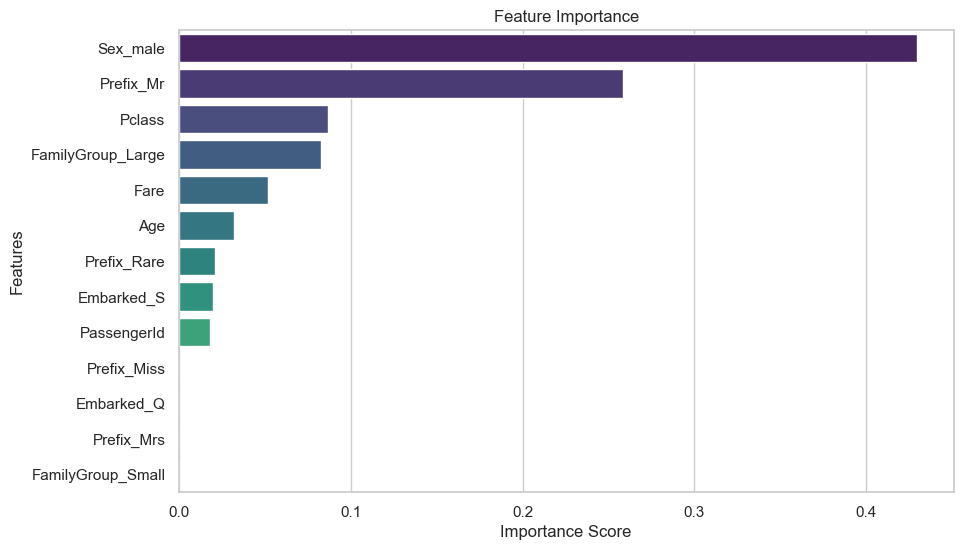

In [777]:
feature_importance = pd.Series(model.feature_importances_, index=X_train.columns)
feature_importance = feature_importance.sort_values(ascending=False)

# วาดกราฟแท่ง

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.values, y=feature_importance.index, palette="viridis")
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

C:\Users\i\AppData\Local\Temp\ipykernel_21092\166431134.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Pclass", y="Survived", data=train, ax=ax[0], palette="muted")
C:\Users\i\AppData\Local\Temp\ipykernel_21092\166431134.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Sex_male", y="Survived", data=train, ax=ax[1], palette="coolwarm")
C:\Users\i\AppData\Local\Temp\ipykernel_21092\166431134.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(["Female", "Male"]) # เปลี่ยนป้ายชื่อให้อ่านง่าย


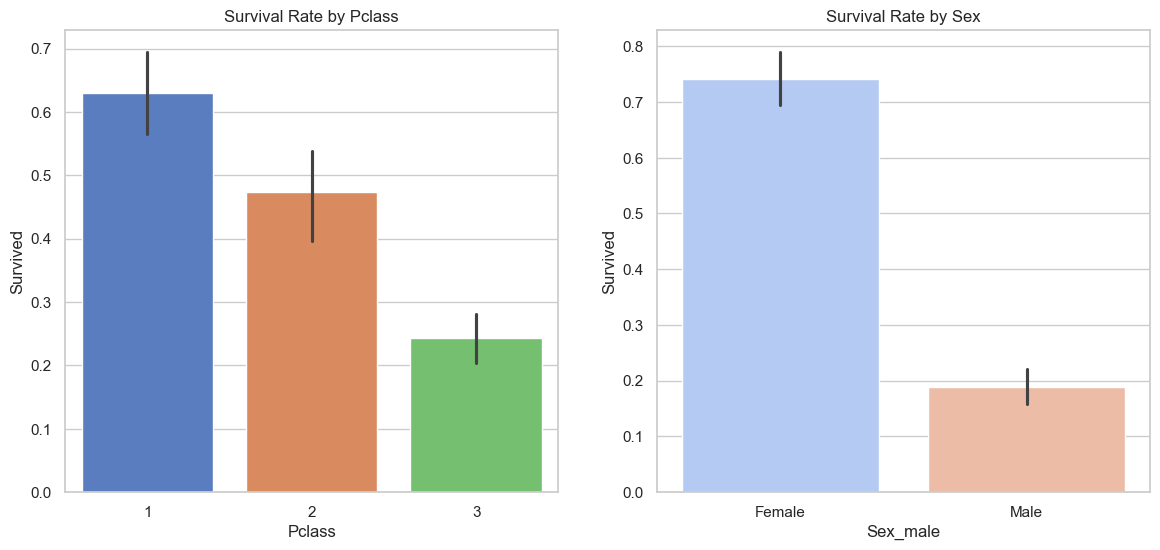

In [778]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# กราฟซ้าย: อัตราการรอดชีวิตตาม Pclass
sns.barplot(x="Pclass", y="Survived", data=train, ax=ax[0], palette="muted")
ax[0].set_title("Survival Rate by Pclass")

# กราฟขวา: อัตราการรอดชีวิตตามเพศ (0 = หญิง, 1 = ชาย ใน Sex_male)
sns.barplot(x="Sex_male", y="Survived", data=train, ax=ax[1], palette="coolwarm")
ax[1].set_xticklabels(["Female", "Male"]) # เปลี่ยนป้ายชื่อให้อ่านง่าย
ax[1].set_title("Survival Rate by Sex")

plt.show()

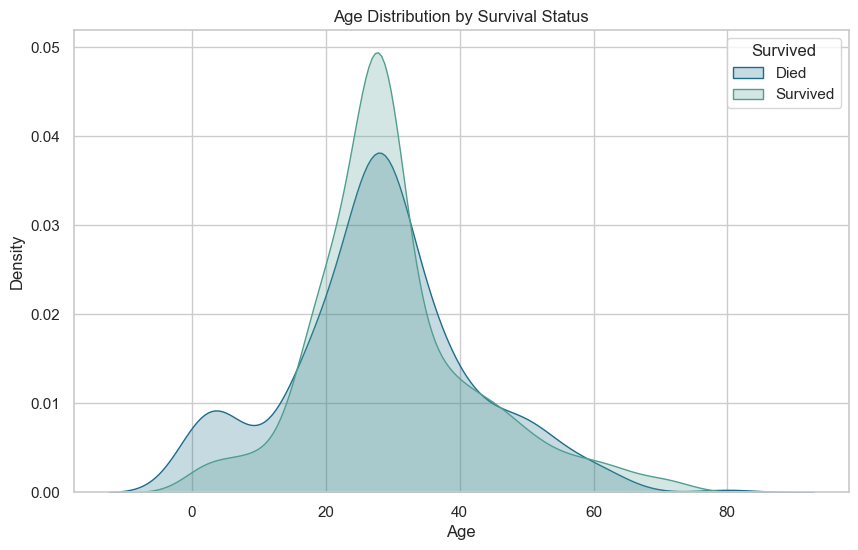

In [779]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=train, x='Age', hue='Survived', fill=True, common_norm=False, palette="crest")
plt.title("Age Distribution by Survival Status")
plt.legend(title="Survived", labels=["Died", "Survived"])
plt.show()

In [780]:
pred_test = model.predict(test)

submisstion = pd.DataFrame({
    "PassengerID": test["PassengerId"],
    "Survived": pred_test
})

submisstion.to_csv("submisstion.csv", index=False)